In [18]:
from sklearn import datasets
import pandas as pd
from plotnine import *
import janitor

In [19]:
avocado = pd.read_csv("C:/Users/USER/Downloads/avocado.csv")
avocado.head(20)
# Check all column names
avocado = avocado.drop(columns=['Unnamed: 0']) # dropping this column because it wont be needed

In [20]:
#  data preparation process
# let us convert to datetime

avocado['Date'] = pd.to_datetime(avocado['Date']).dt.normalize()

# Verify
print(avocado['Date'].dtype) 


datetime64[ns]


In [21]:
#extracting features like month and year
avocado['year'] = avocado['Date'].dt.year
avocado['month'] = avocado['Date'].dt.month
avocado.head(10)

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11
5,2015-11-22,1.26,55979.78,1184.27,48067.99,43.61,6683.91,6556.47,127.44,0.0,conventional,2015,Albany,11
6,2015-11-15,0.99,83453.76,1368.92,73672.72,93.26,8318.86,8196.81,122.05,0.0,conventional,2015,Albany,11
7,2015-11-08,0.98,109428.33,703.75,101815.36,80.00,6829.22,6266.85,562.37,0.0,conventional,2015,Albany,11
8,2015-11-01,1.02,99811.42,1022.15,87315.57,85.34,11388.36,11104.53,283.83,0.0,conventional,2015,Albany,11
9,2015-10-25,1.07,74338.76,842.40,64757.44,113.00,8625.92,8061.47,564.45,0.0,conventional,2015,Albany,10


In [22]:
avocado2 = avocado.clean_names()
avocado2


,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico,2
18245,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico,1
18246,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico,1
18247,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico,1


In [23]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,confusion_matrix, 
                             precision_score, 
                             recall_score,
                             classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

## LOGISTIC REGRESSION

In [24]:
# firstly we encode Target Variable ──────────────────────────────────────────
avocado2['type_encoded'] = avocado2['type'].map({
    'conventional' : 0,
    'organic'      : 1
})

print(avocado2['type_encoded'].value_counts())
# Define Features and Target 
features = [
    'averageprice',
    'total_volume',
    'year',
    'month'
]

X = avocado2[features]
y = avocado2['type_encoded'] # target



# Split Data using size of 80, 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

type_encoded
0    9126
1    9123
Name: count, dtype: int64


In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)
print(y_train.shape)

#  Train Model
avocado_log = LogisticRegression(max_iter=1000, random_state=42)
avocado_log.fit(X_train, y_train)

y_pred = avocado_log.predict(X_test)

# Evaluate 
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print("     LOGISTIC REGRESSION RESULTS")
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
#  this model correctly identifies organic vs conventional avocados 90% (accuracy) of the time 
# just by looking at price, volume, year and month. 

(14599, 4)
(3650, 4)
(3650,)
(14599,)
     LOGISTIC REGRESSION RESULTS
  Accuracy  : 0.9066  (90.7%)
  Precision : 0.8916
  Recall    : 0.9262


In [26]:
avocado_log.coef_

array([[ 4.28136491e+00, -9.57398799e-06, -1.79654069e-03,
        -1.04829072e-01]])

In [27]:
avocado_log.intercept_

array([-0.0008757])

In [28]:
lr = pd.DataFrame(avocado_log.coef_.T, X_train.columns, columns = ["Coefficient"])

lr

,Coefficient
averageprice,4.281365
total_volume,-0.000010
year,-0.001797
month,-0.104829


In [29]:
lr = pd.DataFrame(np.exp(avocado_log.coef_), columns =  X_train.columns)

lr
# this shows that average price is a strong predictor
# For every $1 increase in price, the avocado is 55 times more likely to be organic than conventional!
# while for volume, the odds are very low, it tells us almost nothing
# same with year and month

,averageprice,total_volume,year,month
0,72.339109,0.99999,0.998205,0.900478


In [30]:
from sklearn import metrics

In [31]:
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1820
           1       0.89      0.93      0.91      1830

    accuracy                           0.91      3650
   macro avg       0.91      0.91      0.91      3650
weighted avg       0.91      0.91      0.91      3650



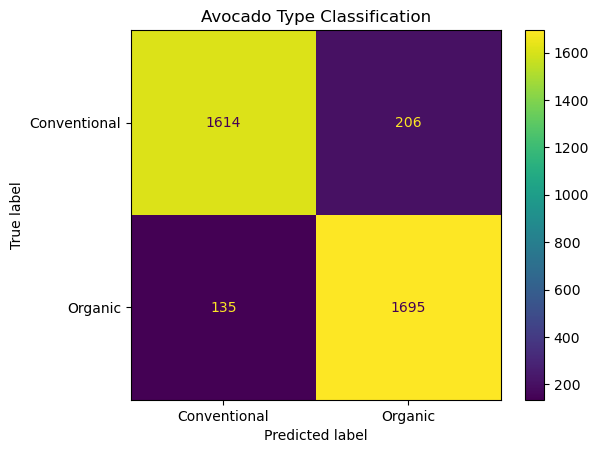

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
# Add the display_labels parameter
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Conventional', 'Organic'], # 0 comes first, then 1
    cmap='viridis' # You can also change the color theme here!
)

plt.title("Avocado Type Classification")
plt.show()

### PCA

In [33]:
# let us standardize the Xtrain and X test and turn them into dataframes
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_ft = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_ft = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)
X_train_scaled_ft.head(7)
X_test_scaled_ft.head(7)

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# next we need to initiate the PCA model with no n components to the scaled training data
from sklearn.decomposition import PCA
pca= PCA()
pca.fit(X_train_scaled_ft)

X_train_scaled_trans = pca.transform(X_train_scaled_ft)
print(X_train_scaled_ft.shape)
print(X_train_scaled_trans.shape)

In [ ]:
# Get the percentage of variance explained by each component
explained_variance = pca.explained_variance_ratio_
explained_variance
explained_variance_ft = pd.DataFrame({"values": range(1, 5),
             "explained_variance": explained_variance})

explained_variance_ft.head()
from plotnine import *
p1 = (ggplot(explained_variance_ft, aes("values", "explained_variance"))
+ geom_col(fill = "green")
+ geom_line()
+ geom_point()
+ theme_minimal())
p1.show()


loadings = pd.DataFrame(pca.components_.T, columns = [f'PC{i+1}' for i in range(len(X_train_scaled_ft.columns))], index = X_train_scaled_ft.columns)
print(loadings)



## PC1 (~0.5): This captures 50% of all the patterns in the data by itself.(likely the 4046 avocado)

## PC2 (~0.3): This captures another 29%.

## PC3 (~0.2): This captures the remaining 20%.

## PC4 (0.0): This captures nothing. It’s essentially empty.
## Therefore, picking the number of components using the elbow method the point where the line stops dropping sharply and starts to flatten out.
## that is from 1 to 2 and then 2 to 3
## At this point, we are picking only 3 PCA because the 4th one captures nothing(0%) while the remaining 3 captures 99.5% of the data.


In [ ]:
# after choosing 3 number of components, let us fit and transform the pca model
from sklearn.decomposition import PCA
pca_2 = PCA(n_components = 3)
pca_2.fit(X_train_scaled_ft)
X_pca2_transform = pca_2.transform(X_train_scaled_ft)
X_pca2_transform

In [ ]:
avocado2_ft = pd.DataFrame({"pca_1": X_pca2_transform[:, 0],
                              "pca_2": X_pca2_transform[:, 1]})


avocado2_ft["type_encoded"] = y_train.values
avocado2_ft["type_label"] = avocado2_ft["type_encoded"].map({
    0: 'Conventional', 1: 'Organic'
})

avocado2_ft["type_encoded"] = avocado2_ft["type_encoded"].astype(int)
avocado2_ft["type_encoded"] = pd.Categorical(avocado2_ft["type_encoded"],
                                        categories = [ 0,1])
# This makes your plots show 'Conventional' and 'Organic' 
# instead of just 0 and 1
avocado2_ft["type_label"] = avocado2["type_encoded"].map({0: 'Conventional', 1: 'Organic'})
avocado2_ft.head()

avocado2_ft["type_encoded"] = avocado2_ft["type_encoded"].cat.remove_unused_categories()

# Create the plot using only TWO PCA dimensions for the axes
(ggplot(avocado2_ft, aes(x="pca_1", y="pca_2", color="type_label"))
 + geom_point(alpha=0.5) # alpha=0.5 helps see overlapping points
 + theme_minimal()
 + labs(title="Avocado PCA: Organic vs Conventional Clusters",
        x="Principal Component 1",
        y="Principal Component 2",
        color="Avocado Type")
 + scale_color_brewer(type="qual", palette="Set1")
)


In [ ]:
# now test your model on the training data
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(avocado2_ft[["pca_1", "pca_2","pca_3"]], y_train)
model.intercept_
model.coef_
import numpy as np

np.exp(model.coef_)
# evaluate the model
X_pred = model.predict(avocado2_ft[["pca_1", "pca_2"]])
print(X_pred)
from sklearn import metrics
print("\n Classification report for classifier %s:\n%s\n"
      % (model, metrics.classification_report(y_train, X_pred)))

# test the model
# using the standardized test model that is a dataframe, let us transform it
X_pca_transform = pca_2.transform(X_test_scaled_ft)

X_pca_transform.shape

X_pca_test_ft2 = pd.DataFrame({"pca_1": X_pca_transform[:, 0],
                              "pca_2": X_pca_transform[:, 1]})
y_predictions = model.predict(X_pca_test_ft2 )
y_predictions

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# let us do confusion matrix for PCA
# Add the display_labels parameter
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_predictions, 
    display_labels=['Conventional', 'Organic'], # 0 comes first, then 1
    cmap='viridis' 
)

plt.title("Avocado Type Classification by PCA")
plt.show()


# Since we chose the Logistic regression over PCA let us make predictions on the test data

In [ ]:
y_pred1 = avocado_log.predict(X_test)
y_pred1[0:20]

In [ ]:
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred1))

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
# Add the display_labels parameter
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred1, 
    display_labels=['Conventional', 'Organic'], # 0 comes first, then 1
    cmap='viridis' # You can also change the color theme here!
)

plt.title("Avocado Type Classification on Test")
plt.show()

# Insights
## Logistic Regression
1.	True Negatives (Top-Left): These are the conventional avocados the model correctly identified as conventional. The model correctly classified the majority of conventional transactions, confirming that conventional avocados occupy a distinct and consistent price range.
2.	True Positives (Bottom-Right): These are the organic avocados the model correctly identified as organic. The high number of true positives confirms that organic avocados are consistently priced higher, making them reliably distinguishable.
3.	False Positives (Top-Right): The model predicted these were organic but they were actually conventional. These represent cases where conventional avocados were priced unusually high, causing the model to misclassify them.
4.	False Negatives (Bottom-Left): The model predicted these were conventional but they were actually organic. These represent organic avocados priced unusually low — the only scenario where the price signal fails.
5.	The price difference between organic and conventional avocados is so consistent that a logistic regression model can identify avocado type with over 90% accuracy using price alone.
6.	There is very little middle ground where organic and conventional avocados overlap in price — they occupy distinct price neighbourhoods in the data.
7.	The odds ratio analysis confirmed that for every $1 increase in average price, the avocado is 55 times more likely to be organic — making average price the dominant predictor by a very large margin.
8. The model correctly identifies 90% of avocados. It missed 135 organic avocados (False Negatives) and incorrectly labelled 206 conventional avocados as organic (False Positives).


## PCA
1.	PC1 captures approximately 50% of all the variance in the dataset. It is heavily influenced by volume-related features — particularly the 4046 PLU code — suggesting that sales volume is the primary source of variation in avocado data.
2.	PC2 captures approximately 29% of the variance, representing the second most important pattern in the data — likely capturing price-related variation distinct from volume.
3.	PC3 captures approximately 20% of the variance. Together the three components explain 99.5% of all information in the dataset.
4.	PC4 captures essentially nothing — 0% — confirming that only 3 components are needed and the fourth adds no value.
5.	The PCA scatter plot shows visible overlap between organic and conventional clusters, explaining why the PCA-based logistic regression achieves 83% accuracy compared to 90% for the standard model. PCA compresses information and loses some of the fine-grained price distinction that separates the two types.
6.	The 3 chosen components were justified using the elbow method — the scree plot shows a sharp drop between components 1 and 2, then again between 2 and 3, with the curve flattening completely at component 4.


## Conclusion
1.	The standard logistic regression outperforms the PCA model on all accuracy metrics because price is the dominant predictor and is preserved in full in the original features but compressed in the PCA components.
2.	The PCA model is valuable not for its accuracy but for its dimensionality reduction and it proves that 99.5% of the information in 4 features can be represented using just 3 components.
3.	While the logistic regression has higher accuracy, the PCA model successfully visualises the separation between organic and conventional avocados in two dimensions — something the standard model cannot do.



   